In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df=pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X=df[['sepal_length','sepal_width']]
y=df['species']

Train test Split

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

#model
model=KNeighborsClassifier(n_neighbors=3)
model.fit(X_train,y_train)

#prediction
y_pred=model.predict(X_test)

#accuracy
accuracy=accuracy_score(y_test,y_pred)

print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.7555555555555555


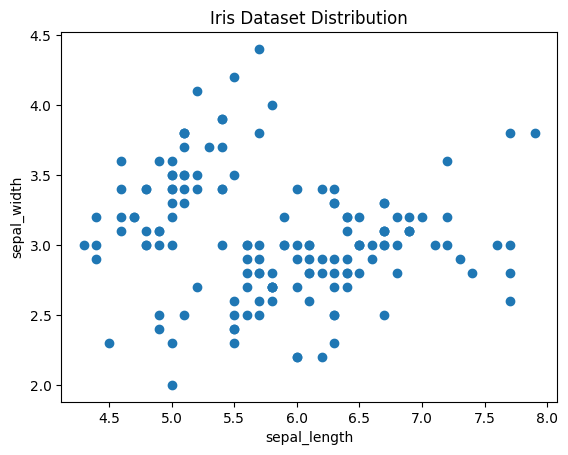

In [5]:
plt.scatter(df['sepal_length'],df['sepal_width'])
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.title("Iris Dataset Distribution")
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [7]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
X=df[['sepal_length','sepal_width']]
y=df['species']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

model=SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [9]:
y_pred=model.predict(X_test)
print("SVC Accuracy:",accuracy_score(y_test,y_pred))

SVC Accuracy: 0.8


Super Vector Regression

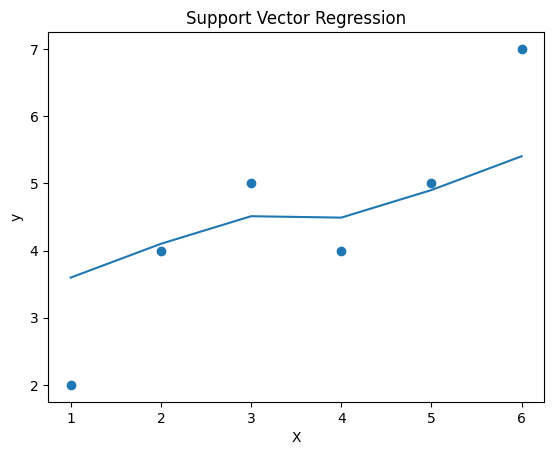

In [10]:
from sklearn.svm import SVR

#dataset
X=np.array([1,2,3,4,5,6]).reshape(-1,1)
y=np.array([2,4,5,4,5,7])

#model
model=SVR(kernel='rbf')
model.fit(X,y)

#Prediction
y_pred=model.predict(X)

#Plot
plt.scatter(X,y)
plt.plot(X,y_pred)
plt.title('Support Vector Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve,roc_auc_score


Load Dataset

In [12]:
url="https://raw.githubusercontent.com/plotly/datasets/master/data.csv"
df=pd.read_csv(url,header=None)
df.head()

/tmp/ipykernel_4911/3050107009.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(url,header=None)


,0,1,2,3,4,5,6,7,8,9,10
0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766126609,45,2,0.802982129,9120,13,0,6,0,2
2,0,0.957151019,40,0,0.121876201,2600,4,0,0,0,1
3,0,0.65818014,38,1,0.085113375,3042,2,1,0,0,0
4,0,0.233809776,30,0,0.036049682,3300,5,0,0,0,0


AUC-ROC Curve

In [ ]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

#convert labels
y=y.replace({'M':1,'B':0})

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)

y_prob=model.predict_proba(X_test)[:,1]

fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc=roc_auc_score(y_test,y_prob)